## Import necessary library


In [60]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from util.parse_loc import (
    load_rolling_window_forecast,
    load_rolling_window_forecast_simple,
)

In [61]:
# Force reload the module
import importlib
import util.parse_loc

importlib.reload(util.parse_loc)
from util.parse_loc import (
    load_rolling_window_forecast,
    load_rolling_window_forecast_simple,
)

## Load The DataFrame from the models forecasted folder


In [62]:
from util.data_path import LSTM_5T_for as forecast_folder_path

In [63]:
forecast_folder = forecast_folder_path

crops = {
    "Cassava": "cassava_rolling_window_forecast.txt",
    "Corn": "corn_rolling_window_forecast.txt",
    "Green Bean": "green_bean_rolling_window_forecast.txt",
    "Soybean": "soybean_rolling_window_forecast.txt",
}

In [64]:
crop_data = {}

for crop_name, file_name in crops.items():
    file_path = os.path.join(forecast_folder, file_name)

    if os.path.exists(file_path):
        try:
            print(f"Attempting to load {crop_name} from {file_name}...")
            dates, prices = load_rolling_window_forecast_simple(file_path)
            crop_data[crop_name] = {"dates": dates, "prices": prices}
            print(f"✓ Loaded {crop_name} data: {len(prices)} price points")
            if len(prices) > 0:
                print(f"  First few prices: {prices[:3]}")
                print(
                    f"  Date range: {dates[0].strftime('%Y-%m-%d') if dates else 'No dates'} to {dates[-1].strftime('%Y-%m-%d') if dates else 'No dates'}"
                )
        except Exception as e:
            print(f"✗ Error loading {crop_name}: {e}")
            crop_data[crop_name] = {"dates": [], "prices": []}
    else:
        print(f"✗ Warning: {file_path} not found")
        crop_data[crop_name] = {"dates": [], "prices": []}

print(
    f"\nLoaded data for {len([k for k, v in crop_data.items() if len(v['prices']) > 0])} crops out of {len(crop_data)} total"
)

crop_price_avg = {}

for crop_name, data in crop_data.items():
    dates = data["dates"]
    prices = data["prices"]

    if len(prices) > 0:
        avg_price = np.round(np.mean(prices), 2)
        crop_price_avg[crop_name] = avg_price
        print(f"{crop_name} average price: {avg_price:.2f}")
    else:
        print(f"No price data available for {crop_name}")

Attempting to load Cassava from cassava_rolling_window_forecast.txt...
✓ Loaded Cassava data: 12 price points
  First few prices: [3.16, 3.19, 3.03]
  Date range: 2024-01-01 to 2024-12-01
Attempting to load Corn from corn_rolling_window_forecast.txt...
✓ Loaded Corn data: 12 price points
  First few prices: [11.67, 12.94, 14.13]
  Date range: 2024-01-01 to 2024-12-01
Attempting to load Green Bean from green_bean_rolling_window_forecast.txt...
✓ Loaded Green Bean data: 12 price points
  First few prices: [24.2, 23.33, 22.77]
  Date range: 2024-01-01 to 2024-12-01
Attempting to load Soybean from soybean_rolling_window_forecast.txt...
✓ Loaded Soybean data: 12 price points
  First few prices: [22.45, 25.24, 26.38]
  Date range: 2024-01-01 to 2024-12-01

Loaded data for 4 crops out of 4 total
Cassava average price: 2.82
Corn average price: 12.33
Green Bean average price: 24.54
Soybean average price: 22.55


In [65]:
# Debug: Check file paths and existence
print("Debug Information:")
print(f"Forecast folder path: {forecast_folder}")
print(f"Folder exists: {os.path.exists(forecast_folder)}")
print("\nChecking individual files:")

for crop_name, file_name in crops.items():
    file_path = os.path.join(forecast_folder, file_name)
    print(f"{crop_name}: {file_path}")
    print(f"  File exists: {os.path.exists(file_path)}")

    if os.path.exists(file_path):
        # Try to read first few lines of the file
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                lines = f.readlines()[:10]  # First 10 lines
            print(f"  File has {len(lines)} lines (showing first 10):")
            for i, line in enumerate(lines):
                print(f"    {i + 1}: {line.strip()}")
        except Exception as e:
            print(f"  Error reading file: {e}")
    print()

Debug Information:
Forecast folder path: c:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\forecast_price\LSTM-5T
Folder exists: True

Checking individual files:
Cassava: c:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\forecast_price\LSTM-5T\cassava_rolling_window_forecast.txt
  File exists: True
  File has 10 lines (showing first 10):
    1: LSTM Rolling Window Forecast Results for Cassava Prices - 20251014_161153
    2: ================================================================================
    3: 
    4: Rolling Window Configuration:
    5: ------------------------------
    6: Window Size: 7 years
    7: Total Windows: 1
    8: First Training Period: 2017-2023
    9: Last Training Period: 2017-2023
    10: Prediction Years: [2024]

Corn: c:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\forecast_price\LSTM-5T\corn_rolling_window_forecast.txt
  File exists: True
  File has 10 line

In [66]:
# Debug the parsing step by step
test_file = os.path.join(forecast_folder, "cassava_rolling_window_forecast.txt")
print(f"Testing parsing step by step with: {test_file}")

with open(test_file, "r", encoding="utf-8") as file:
    lines = file.readlines()

reading_forecast_data = False
found_training_line = False

for i, line in enumerate(lines):
    line_stripped = line.strip()

    # Show first 20 lines with conditions
    if i < 20:
        print(f"Line {i + 1}: '{line_stripped}'")

        if "Training:" in line_stripped and "Predicting:" in line_stripped:
            print(f"  -> Found training line! Setting reading_forecast_data = True")
            reading_forecast_data = True
            found_training_line = True
            continue

        if found_training_line and ":" in line_stripped:
            print(
                f"  -> Found colon line while reading_forecast_data = {reading_forecast_data}"
            )
            print(f"  -> Starts with Window? {line_stripped.startswith('Window')}")
            print(f"  -> Starts with Overall? {line_stripped.startswith('Overall')}")
            print(f"  -> Starts with ----? {line_stripped.startswith('----')}")
            print(f"  -> Contains ': '? {': ' in line_stripped}")
            print(f"  -> Contains '-'? {'-' in line_stripped}")

            if (
                reading_forecast_data
                and ":" in line_stripped
                and not line_stripped.startswith("Window")
                and not line_stripped.startswith("Overall")
                and not line_stripped.startswith("----")
            ):
                print(f"  -> Should parse this line!")
                if ": " in line_stripped:
                    try:
                        date_str, price_str = line_stripped.rsplit(": ", 1)
                        print(f"    -> Split: date='{date_str}', price='{price_str}'")
                        if "-" in date_str:
                            date = pd.to_datetime(date_str)
                            price = float(price_str)
                            print(f"    -> Parsed successfully: {date}, {price}")
                        else:
                            print(f"    -> No hyphen in date part")
                    except Exception as e:
                        print(f"    -> Error parsing: {e}")
                else:
                    print(f"    -> No ': ' found")
            else:
                print(f"  -> Skipping this line")

        print()

Testing parsing step by step with: c:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\forecast_price\LSTM-5T\cassava_rolling_window_forecast.txt
Line 1: 'LSTM Rolling Window Forecast Results for Cassava Prices - 20251014_161153'

Line 2: '================================================================================'

Line 3: ''

Line 4: 'Rolling Window Configuration:'

Line 5: '------------------------------'

Line 6: 'Window Size: 7 years'

Line 7: 'Total Windows: 1'

Line 8: 'First Training Period: 2017-2023'

Line 9: 'Last Training Period: 2017-2023'

Line 10: 'Prediction Years: [2024]'

Line 11: ''

Line 12: 'Window 14 - Training: 2017-2023, Predicting: 2024'
  -> Found training line! Setting reading_forecast_data = True
Line 13: '--------------------------------------------------'

Line 14: '2024-01-01: 3.16'
  -> Found colon line while reading_forecast_data = True
  -> Starts with Window? False
  -> Starts with Overall? False
  -> Starts with ----

## Normalized the data for each crops


In [67]:
for crop_name, data in crop_data.items():
    new_data_lst = []

    # Access the 'prices' list from the data dictionary
    for price in data["prices"]:
        if price != 0:
            new_data_lst.append(price / float(crop_price_avg[crop_name]))

    # Update the prices with normalized values
    crop_data[crop_name]["prices"] = new_data_lst

In [68]:
def find_intersections(dates1, prices1, dates2, prices2):
    """
    Find intersection points between two price curves
    """
    intersections = []

    # Find common dates between the two datasets
    common_dates = []
    common_prices1 = []
    common_prices2 = []

    for i, date1 in enumerate(dates1):
        if date1 in dates2:
            j = dates2.index(date1)
            common_dates.append(date1)
            common_prices1.append(prices1[i])
            common_prices2.append(prices2[j])

    # Find sign changes in price differences (indicates intersection)
    for i in range(len(common_prices1) - 1):
        diff1 = common_prices1[i] - common_prices2[i]
        diff2 = common_prices1[i + 1] - common_prices2[i + 1]

        # Check if there's a sign change (intersection)
        if diff1 * diff2 < 0:
            # Linear interpolation to find exact intersection point
            t = abs(diff1) / (abs(diff1) + abs(diff2))
            intersect_date = (
                common_dates[i] + (common_dates[i + 1] - common_dates[i]) * t
            )
            intersect_price = (
                common_prices1[i] + (common_prices1[i + 1] - common_prices1[i]) * t
            )

            intersections.append((intersect_date, intersect_price))

    return intersections

In [69]:
# Configuration and styling
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fill_colors = colors
line_styles = ["-"] * 4


def calculate_statistics(crop_data):
    """Calculate comprehensive statistics for all crops"""
    all_prices = []
    for data in crop_data.values():
        all_prices.extend(data["prices"])

    stats = {
        "avg_normalized": np.mean(all_prices),
        "std_normalized": np.std(all_prices),
        "num_crops": len(crop_data),
    }
    return stats, all_prices


def plot_crop_lines(ax, crop_data, colors, fill_colors):
    """Plot crop price lines with fill areas"""
    for i, (crop_name, data) in enumerate(crop_data.items()):
        # Convert datetime to integer indices for consistent plotting
        date_indices = list(range(len(data["dates"])))

        ax.plot(
            date_indices,
            data["prices"],
            color=colors[i],
            linewidth=2.5,
            linestyle="-",
            label=crop_name,
            alpha=0.9,
        )
        # Fill between removed to eliminate fill color under the graphs


def find_peak_prices(crop_data):
    """Find the local peak price for each crop"""
    peak_prices = {}

    for crop_name, data in crop_data.items():
        if data["prices"]:
            # Find the maximum price and its index
            peak_price = max(data["prices"])
            peak_index = data["prices"].index(peak_price)
            peak_date = data["dates"][peak_index]

            peak_prices[crop_name] = {
                "price": peak_price,
                "date": peak_date,
                "index": peak_index,
            }

    return peak_prices


def style_plot(ax, title, xlabel, ylabel):
    """Apply consistent styling to plot"""
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.legend(
        loc="upper right",
    )
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

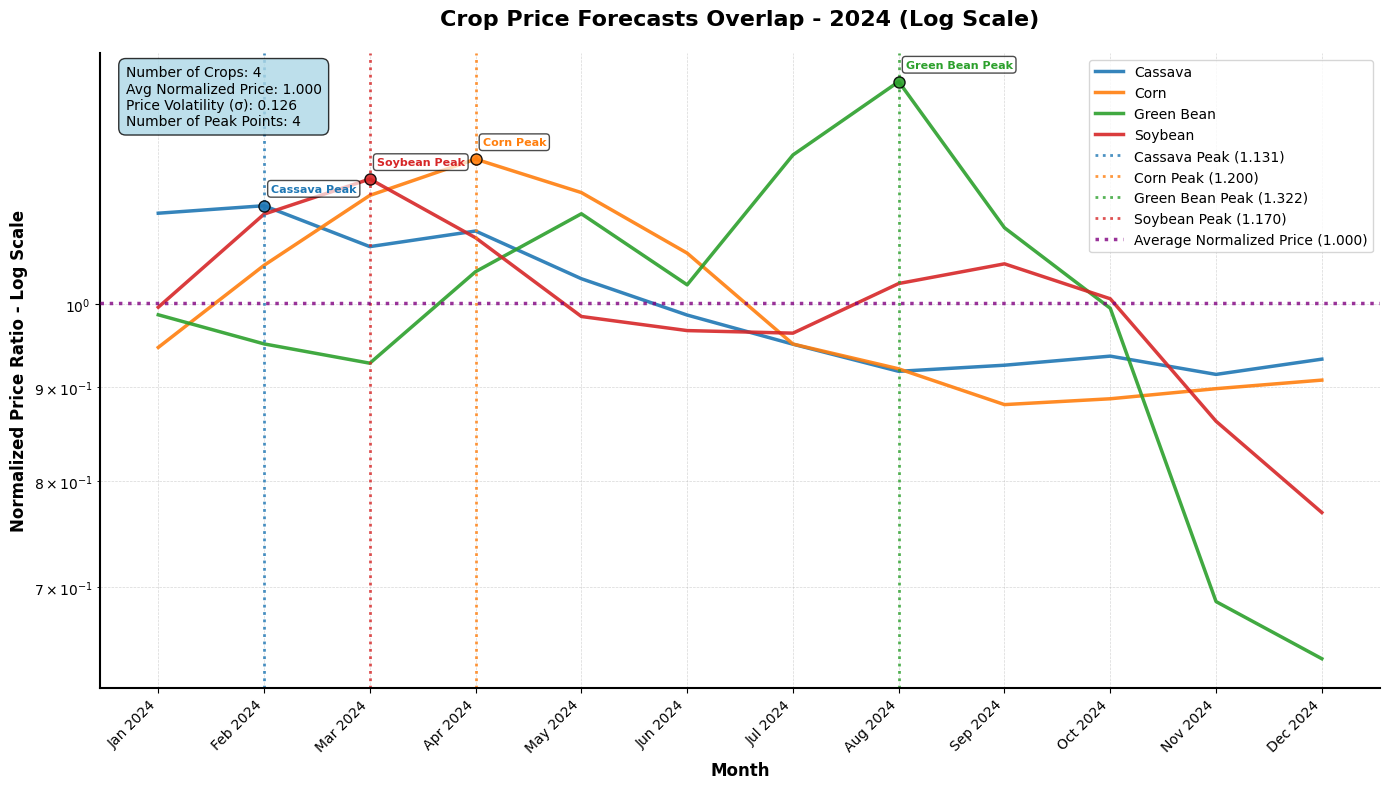

In [70]:
# Main plotting function
def create_crop_analysis_plot():
    """Create comprehensive crop price analysis plot"""
    stats, all_prices = calculate_statistics(crop_data)

    plt.figure(figsize=(14, 8))
    ax = plt.gca()

    # Plot crop lines and fill areas
    plot_crop_lines(ax, crop_data, colors, fill_colors)

    # Find peak prices for each crop
    peak_prices = find_peak_prices(crop_data)

    # Plot vertical dotted lines at each crop's peak date
    for i, (crop_name, peak_info) in enumerate(peak_prices.items()):
        peak_price = peak_info["price"]
        peak_index = peak_info["index"]
        peak_date = peak_info["date"]

        # Add vertical dotted line at peak date
        ax.axvline(
            x=peak_index,
            color=colors[i],
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label=f"{crop_name} Peak ({peak_price:.3f})",
        )

        # Add a marker at the peak point
        ax.plot(
            peak_index,
            peak_price,
            "o",
            markersize=8,
            markerfacecolor=colors[i],
            markeredgecolor="black",
            zorder=10,
            alpha=0.9,
        )

        # Add annotation for the peak point
        ax.annotate(
            f"{crop_name} Peak",
            (peak_index, peak_price),
            xytext=(5, 10),
            textcoords="offset points",
            fontsize=8,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7),
            color=colors[i],
            fontweight="bold",
        )

    # Add average price line
    avg_price = stats["avg_normalized"]
    ax.axhline(
        y=avg_price,
        color="purple",
        linestyle=":",
        linewidth=2.5,
        label=f"Average Normalized Price ({avg_price:.3f})",
        alpha=0.8,
        zorder=5,
    )

    # Set log scale and styling
    ax.set_yscale("log")
    style_plot(
        ax,
        "Crop Price Forecasts Overlap - 2024 (Log Scale)",
        "Month",
        "Normalized Price Ratio - Log Scale",
    )

    # Create a list of all dates from one of the crop datasets (assuming all have same dates)
    example_crop = list(crop_data.keys())[0]
    all_dates = crop_data[example_crop]["dates"]

    # Format the dates as month names
    month_labels = [d.strftime("%b %Y") for d in all_dates]

    # Set the x-ticks to be at the date positions
    ax.set_xticks(range(len(all_dates)))
    ax.set_xticklabels(month_labels)

    # Add statistics text box
    stats_text = (
        f"Number of Crops: {stats['num_crops']}\n"
        f"Avg Normalized Price: {stats['avg_normalized']:.3f}\n"
        f"Price Volatility (σ): {stats['std_normalized']:.3f}\n"
        f"Number of Peak Points: {len(peak_prices)}"
    )

    ax.text(
        0.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="lightblue",
            alpha=0.8,
            edgecolor="black",
        ),
    )

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return peak_prices


peak_prices = create_crop_analysis_plot()